# Customer Comments Data Analysis - Exploration Notebook

## Overview
This notebook presents a comprehensive exploratory data analysis (EDA) of customer feedback dataset. The analysis encompasses data loading, cleaning, statistical evaluation, and visualization of customer comments across multiple dimensions.

---

## 1. Setup and Data Ingestion

### 1.1 Environment Configuration
Import required libraries for data manipulation, analysis, and visualization.

In [2]:
%pip install matplotlib
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.


In [ ]:
df = pd.read_csv("../data/customer_comment.csv", encoding='latin-1')


## 2. Data Structure and Initial Examination

### 2.1 Dataset Overview
Comprehensive visualization of dataset structure, data types, and descriptive statistics.

In [4]:
df

,Review Title,Customer name,Rating,Date,Category,Comments,Useful
0,Another Midrange killer Smartphone by Xiaomi,Rishikumar Thakur,4.0 out of 5 stars,on 1 October 2018,Display,Another Midrange killer Smartphone by Xiaomi\n...,
1,vry small size mobile,Raza ji,3.0 out of 5 stars,on 15 September 2018,Others,All ok but vry small size mobile,7 people found this helpful
2,Full display not working in all application.,Vaibhav Patel,3.0 out of 5 stars,on 18 September 2018,Others,Quite good,7 people found this helpful
3,Value for Money,Amazon Customer,5.0 out of 5 stars,on 28 September 2018,Display,Redmi has always have been the the king of bud...,2 people found this helpful
4,Not worth for the money,Sudhakaran Wadakkancheri,2.0 out of 5 stars,on 18 September 2018,Others,worst product from MI. I am a hardcore fan of ...,6 people found this helpful
...,...,...,...,...,...,...,...
275,"Cemera quality,face unlock most important in t...",Rahul,5.0 out of 5 stars,on 19 September 2018,Others,"I like This Phone, Awesome look and design.\nI...",NaN
276,Mi is best phone,Sunil Soni,4.0 out of 5 stars,on 18 September 2018,Others,Product is avasome but invoice is note include...,NaN
277,Its a OK Phone,D.C.Padhi,3.0 out of 5 stars,on 15 September 2018,Battery,"Redmi Note4, Note5, now 6pro..It seems the old...",NaN
278,Redmi,Mahesh,5.0 out of 5 stars,on 21 September 2018,Others,I love mi,NaN


In [5]:
df.head()

,Review Title,Customer name,Rating,Date,Category,Comments,Useful
0,Another Midrange killer Smartphone by Xiaomi,Rishikumar Thakur,4.0 out of 5 stars,on 1 October 2018,Display,Another Midrange killer Smartphone by Xiaomi\n...,
1,vry small size mobile,Raza ji,3.0 out of 5 stars,on 15 September 2018,Others,All ok but vry small size mobile,7 people found this helpful
2,Full display not working in all application.,Vaibhav Patel,3.0 out of 5 stars,on 18 September 2018,Others,Quite good,7 people found this helpful
3,Value for Money,Amazon Customer,5.0 out of 5 stars,on 28 September 2018,Display,Redmi has always have been the the king of bud...,2 people found this helpful
4,Not worth for the money,Sudhakaran Wadakkancheri,2.0 out of 5 stars,on 18 September 2018,Others,worst product from MI. I am a hardcore fan of ...,6 people found this helpful


In [6]:
df.tail()

,Review Title,Customer name,Rating,Date,Category,Comments,Useful
275,"Cemera quality,face unlock most important in t...",Rahul,5.0 out of 5 stars,on 19 September 2018,Others,"I like This Phone, Awesome look and design.\nI...",NaN
276,Mi is best phone,Sunil Soni,4.0 out of 5 stars,on 18 September 2018,Others,Product is avasome but invoice is note include...,NaN
277,Its a OK Phone,D.C.Padhi,3.0 out of 5 stars,on 15 September 2018,Battery,"Redmi Note4, Note5, now 6pro..It seems the old...",NaN
278,Redmi,Mahesh,5.0 out of 5 stars,on 21 September 2018,Others,I love mi,NaN
279,Not worth for the price.,Vinod,1.0 out of 5 stars,on 17 September 2018,Camera,Same old configurations with higher price.\nNo...,NaN


In [7]:
df.shape

(280, 7)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280 entries, 0 to 279
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Review Title   280 non-null    object
 1   Customer name  280 non-null    object
 2   Rating         280 non-null    object
 3   Date           280 non-null    object
 4   Category       280 non-null    object
 5   Comments       280 non-null    object
 6   Useful         110 non-null    object
dtypes: object(7)
memory usage: 15.4+ KB


In [9]:
df.describe()

,Review Title,Customer name,Rating,Date,Category,Comments,Useful
count,280,280,280,280,280,280,110
unique,198,210,5,17,5,216,12
top,Good,Amazon Customer,5.0 out of 5 stars,on 18 September 2018,Others,Good,
freq,19,43,151,30,180,18,39


In [10]:
df.dtypes

Review Title     object
Customer name    object
Rating           object
Date             object
Category         object
Comments         object
Useful           object
dtype: object

In [11]:
df.nunique()

Review Title     198
Customer name    210
Rating             5
Date              17
Category           5
Comments         216
Useful            12
dtype: int64

## 3. Data Quality Assessment and Cleaning

### 3.1 Missing Values and Duplicate Records Analysis
Identify and quantify data quality issues including null values and duplicate entries.

In [12]:
print("Valores Nulos de cada Colunas:")
df.isnull().sum()

Valores Nulos de cada Colunas:


Review Title       0
Customer name      0
Rating             0
Date               0
Category           0
Comments           0
Useful           170
dtype: int64

In [13]:
df['Useful'].value_counts()

Useful
                                 39
One person found this helpful    24
2 people found this helpful      23
3 people found this helpful       7
5 people found this helpful       5
7 people found this helpful       4
6 people found this helpful       2
10 people found this helpful      2
4 people found this helpful       1
8 people found this helpful       1
11 people found this helpful      1
20 people found this helpful      1
Name: count, dtype: int64

In [14]:
df['Customer name'].value_counts()

Customer name
Amazon Customer             43
KHAN SONU RAFI AHMED         3
Bidyut Majumder              3
Raza ji                      2
Sudhakaran Wadakkancheri     2
                            ..
Rahul                        1
Sunil Soni                   1
D.C.Padhi                    1
Mahesh                       1
Vinod                        1
Name: count, Length: 210, dtype: int64

In [15]:
df.isnull().sum()

Review Title       0
Customer name      0
Rating             0
Date               0
Category           0
Comments           0
Useful           170
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(21)

In [ ]:
df = df.drop_duplicates()

In [18]:
df.shape

(259, 7)

In [ ]:
df = df.drop("Customer name", axis=1)

df.head()

,Review Title,Rating,Date,Category,Comments,Useful
0,Another Midrange killer Smartphone by Xiaomi,4.0 out of 5 stars,on 1 October 2018,Display,Another Midrange killer Smartphone by Xiaomi\n...,
1,vry small size mobile,3.0 out of 5 stars,on 15 September 2018,Others,All ok but vry small size mobile,7 people found this helpful
2,Full display not working in all application.,3.0 out of 5 stars,on 18 September 2018,Others,Quite good,7 people found this helpful
3,Value for Money,5.0 out of 5 stars,on 28 September 2018,Display,Redmi has always have been the the king of bud...,2 people found this helpful
4,Not worth for the money,2.0 out of 5 stars,on 18 September 2018,Others,worst product from MI. I am a hardcore fan of ...,6 people found this helpful


In [ ]:
df["Useful"] = df["Useful"].replace({' ', "nan"}, 0)
df["Useful"] = df["Useful"].str.replace(r'[Oo]ne\s+person.*', '1', regex=True)


df.head()

,Review Title,Rating,Date,Category,Comments,Useful
0,Another Midrange killer Smartphone by Xiaomi,4.0 out of 5 stars,on 1 October 2018,Display,Another Midrange killer Smartphone by Xiaomi\n...,NaN
1,vry small size mobile,3.0 out of 5 stars,on 15 September 2018,Others,All ok but vry small size mobile,7 people found this helpful
2,Full display not working in all application.,3.0 out of 5 stars,on 18 September 2018,Others,Quite good,7 people found this helpful
3,Value for Money,5.0 out of 5 stars,on 28 September 2018,Display,Redmi has always have been the the king of bud...,2 people found this helpful
4,Not worth for the money,2.0 out of 5 stars,on 18 September 2018,Others,worst product from MI. I am a hardcore fan of ...,6 people found this helpful


In [ ]:

def extract_numbers(value):
    numbers = re.search(r'\d+', str(value))
    return int(numbers.group()) if numbers else None


df["Useful"] = df["Useful"].apply(extract_numbers)

df["Useful"] = df["Useful"].fillna(0).astype(int)

df.head()

,Review Title,Rating,Date,Category,Comments,Useful
0,Another Midrange killer Smartphone by Xiaomi,4.0 out of 5 stars,on 1 October 2018,Display,Another Midrange killer Smartphone by Xiaomi\n...,0
1,vry small size mobile,3.0 out of 5 stars,on 15 September 2018,Others,All ok but vry small size mobile,7
2,Full display not working in all application.,3.0 out of 5 stars,on 18 September 2018,Others,Quite good,7
3,Value for Money,5.0 out of 5 stars,on 28 September 2018,Display,Redmi has always have been the the king of bud...,2
4,Not worth for the money,2.0 out of 5 stars,on 18 September 2018,Others,worst product from MI. I am a hardcore fan of ...,6


In [22]:
df["Useful"].values

array([ 0,  7,  7,  2,  6,  2,  3,  5,  5,  2,  4,  3,  3,  2,  1,  2,  1,
        3,  2,  2,  1,  1,  1,  1,  2,  2,  2,  2,  0,  1,  1,  1,  1,  2,
        1,  1,  2,  1,  2,  1,  0,  0,  0,  1,  0,  0,  0,  0,  1,  1,  0,
        1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 10,  0,  0, 10,  8,
       11,  5,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  2,  0,
       20,  0,  0,  0,  3

In [23]:
df["Useful"].value_counts(normalize=True) * 100

Useful
0     79.536680
1      7.335907
2      6.177606
3      2.316602
5      1.158301
7      0.772201
10     0.772201
6      0.386100
4      0.386100
8      0.386100
11     0.386100
20     0.386100
Name: proportion, dtype: float64

In [ ]:
df["Rating"] = df["Rating"].apply(extract_numbers)

df["Rating"] = df["Rating"].astype(float)

df.head()

,Review Title,Rating,Date,Category,Comments,Useful
0,Another Midrange killer Smartphone by Xiaomi,4.0,on 1 October 2018,Display,Another Midrange killer Smartphone by Xiaomi\n...,0
1,vry small size mobile,3.0,on 15 September 2018,Others,All ok but vry small size mobile,7
2,Full display not working in all application.,3.0,on 18 September 2018,Others,Quite good,7
3,Value for Money,5.0,on 28 September 2018,Display,Redmi has always have been the the king of bud...,2
4,Not worth for the money,2.0,on 18 September 2018,Others,worst product from MI. I am a hardcore fan of ...,6


In [ ]:
df["Date"]

0         on 1 October 2018
1      on 15 September 2018
2      on 18 September 2018
3      on 28 September 2018
4      on 18 September 2018
               ...         
275    on 19 September 2018
276    on 18 September 2018
277    on 15 September 2018
278    on 21 September 2018
279    on 17 September 2018
Name: Date, Length: 259, dtype: object

In [26]:
def clean_date(date_str):
    """
    Converte string de data para datetime.
    
    Exemplos:
    - "on 1 October 2018" → datetime(2018, 10, 1)
    - "on 15 September 2018" → datetime(2018, 9, 15)
    - NaN/vazio → NaT (Not a Time)
    
    Args:
        date_str: String com data ou NaN
        
    Returns:
        datetime object ou NaT se inválido
    """
    
    # Se for NaN ou None, retornar NaT
    if pd.isna(date_str):
        return pd.NaT
    
    # Converter para string (caso não seja)
    date_str = str(date_str).strip()
    
    # Se vazio, retornar NaT
    if not date_str or date_str == 'nan':
        return pd.NaT
    
    try:
        # Regex para extrair: dia, mês (texto), ano
        # Padrão: "on 1 October 2018"
        pattern = r'on\s+(\d{1,2})\s+([A-Za-z]+)\s+(\d{4})'
        match = re.search(pattern, date_str)
        
        if match:
            day = int(match.group(1))      # 1, 15, 18, etc
            month_text = match.group(2)    # "October", "September", etc
            year = int(match.group(3))     # 2018
            
            # Converter mês em texto para número
            # Exemplo: "October" → 10, "September" → 9
            date_obj = pd.to_datetime(f"{day} {month_text} {year}", 
                                      format="%d %B %Y")
            return date_obj
        else:
            # Se não encontrar padrão, retornar NaT
            return pd.NaT
            
    except Exception as e:
        print(f"Erro ao processar data '{date_str}': {e}")
        return pd.NaT


df["Date"] = df["Date"].apply(clean_date)


In [ ]:
df

,Review Title,Rating,Date,Category,Comments,Useful
0,Another Midrange killer Smartphone by Xiaomi,4.0,2018-10-01,Display,Another Midrange killer Smartphone by Xiaomi\n...,0
1,vry small size mobile,3.0,2018-09-15,Others,All ok but vry small size mobile,7
2,Full display not working in all application.,3.0,2018-09-18,Others,Quite good,7
3,Value for Money,5.0,2018-09-28,Display,Redmi has always have been the the king of bud...,2
4,Not worth for the money,2.0,2018-09-18,Others,worst product from MI. I am a hardcore fan of ...,6
...,...,...,...,...,...,...
275,"Cemera quality,face unlock most important in t...",5.0,2018-09-19,Others,"I like This Phone, Awesome look and design.\nI...",0
276,Mi is best phone,4.0,2018-09-18,Others,Product is avasome but invoice is note include...,0
277,Its a OK Phone,3.0,2018-09-15,Battery,"Redmi Note4, Note5, now 6pro..It seems the old...",0
278,Redmi,5.0,2018-09-21,Others,I love mi,0


In [ ]:
df["Category"].value_counts().keys()

Index(['Others', 'Display', 'Battery', 'Camera', 'Delivery'], dtype='object', name='Category')

In [29]:
df["Comments"] = df["Comments"].astype("string")
df["Review Title"] = df["Review Title"].astype("string")
df["Category"] = df["Category"].astype("string")

df["Comments"].dtype

string[python]

In [30]:
df.dtypes

Review Title    string[python]
Rating                 float64
Date            datetime64[ns]
Category        string[python]
Comments        string[python]
Useful                   int64
dtype: object

In [ ]:
df["Word_Count"] = df["Comments"].str.split().apply(len)
df["is_useful"] = df["Useful"].apply(lambda x: 1 if x >= 1 else 0)

df.head()

,Review Title,Rating,Date,Category,Comments,Useful,Word_Count,is_useful
0,Another Midrange killer Smartphone by Xiaomi,4.0,2018-10-01,Display,Another Midrange killer Smartphone by Xiaomi\n...,0,837,0
1,vry small size mobile,3.0,2018-09-15,Others,All ok but vry small size mobile,7,7,1
2,Full display not working in all application.,3.0,2018-09-18,Others,Quite good,7,2,1
3,Value for Money,5.0,2018-09-28,Display,Redmi has always have been the the king of bud...,2,146,1
4,Not worth for the money,2.0,2018-09-18,Others,worst product from MI. I am a hardcore fan of ...,6,16,1


In [32]:
df.dtypes



Review Title    string[python]
Rating                 float64
Date            datetime64[ns]
Category        string[python]
Comments        string[python]
Useful                   int64
Word_Count               int64
is_useful                int64
dtype: object

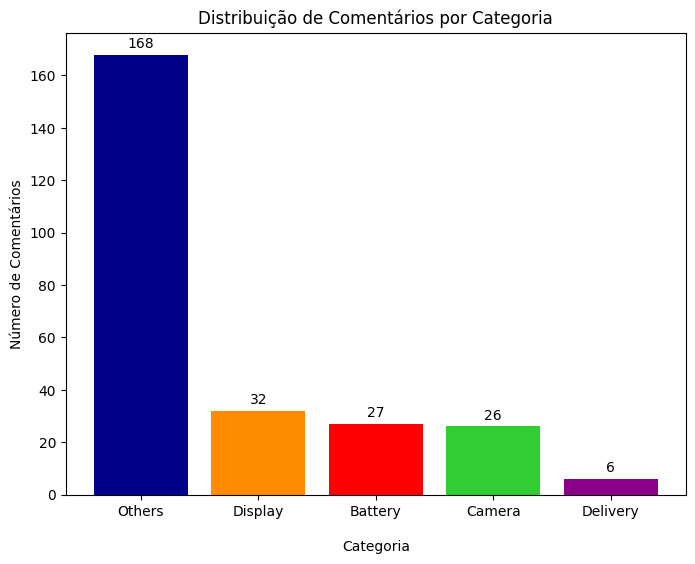

In [ ]:
cores = ['#00008B', '#FF8C00', 'red', '#32CD32', '#8B008B', '#FFD700']

fig, ax = plt.subplots(figsize=(8, 6))

x = np.arange(len(df["Category"].unique()))

grafico = ax.bar(x, df["Category"].value_counts().values, data=df, color=cores)
ax.set_title("Distribuição de Comentários por Categoria")
ax.set_xlabel("\nCategoria")
ax.set_ylabel("Número de Comentários")
ax.set_xticks(x)
ax.set_xticklabels(df["Category"].value_counts().keys())

ax.bar_label(grafico, padding=3)

plt.show()

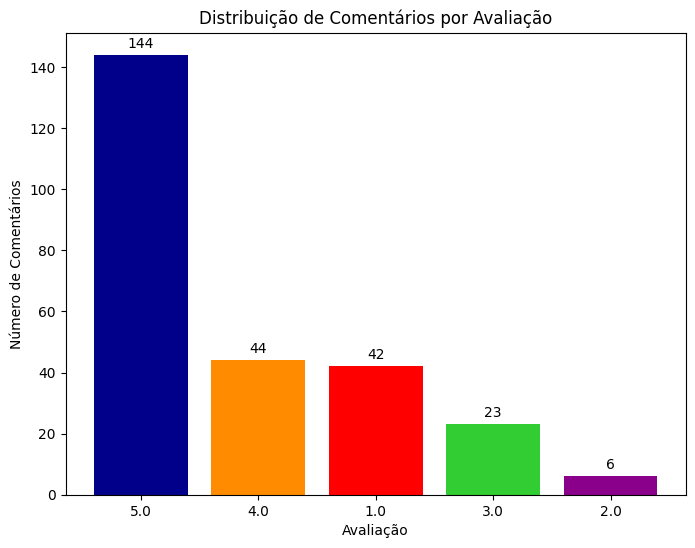

In [ ]:
cores = ['#00008B', '#FF8C00', 'red', '#32CD32', '#8B008B', '#FFD700']

fig, ax = plt.subplots(figsize=(8, 6))

x = np.arange(len(df["Rating"].unique()))

grafico = ax.bar(x, df["Rating"].value_counts().values, data=df, color=cores)
ax.set_title("Distribuição de Comentários por Avaliação")
ax.set_xlabel("Avaliação")
ax.set_ylabel("Número de Comentários")
ax.set_xticks(x)
ax.set_xticklabels(df["Rating"].value_counts().keys())

ax.bar_label(grafico, padding=3)

plt.show()

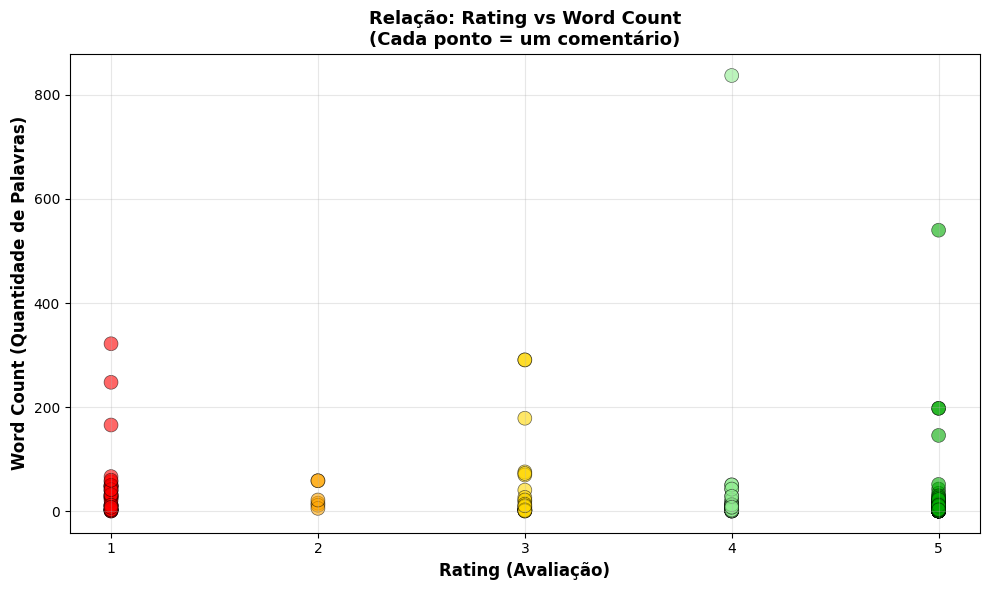

In [ ]:
# Cores baseadas no rating
cores_rating = {
    1.0: '#FF0000',  # Vermelho (muito ruim)
    2.0: '#FFA500',  # Laranja (ruim)
    3.0: '#FFD700',  # Ouro (neutro)
    4.0: '#90EE90',  # Verde claro (bom)
    5.0: '#00AA00'   # Verde escuro (excelente)
}

# Criar figura
fig, ax = plt.subplots(figsize=(10, 6))

# Aplicar cores a cada ponto
colors = [cores_rating.get(rating, '#808080') for rating in df["Rating"]]

scatter = ax.scatter(df["Rating"], df["Word_Count"], 
                     c=colors, alpha=0.6, s=100, edgecolors='black', linewidth=0.5)

ax.set_xlabel("Rating (Avaliação)", fontsize=12, fontweight='bold')
ax.set_ylabel("Word Count (Quantidade de Palavras)", fontsize=12, fontweight='bold')
ax.set_title("Relação: Rating vs Word Count\n(Cada ponto = um comentário)", 
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.show()

C:\Users\carlo\AppData\Local\Temp\ipykernel_18908\1223361086.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_por_rating,


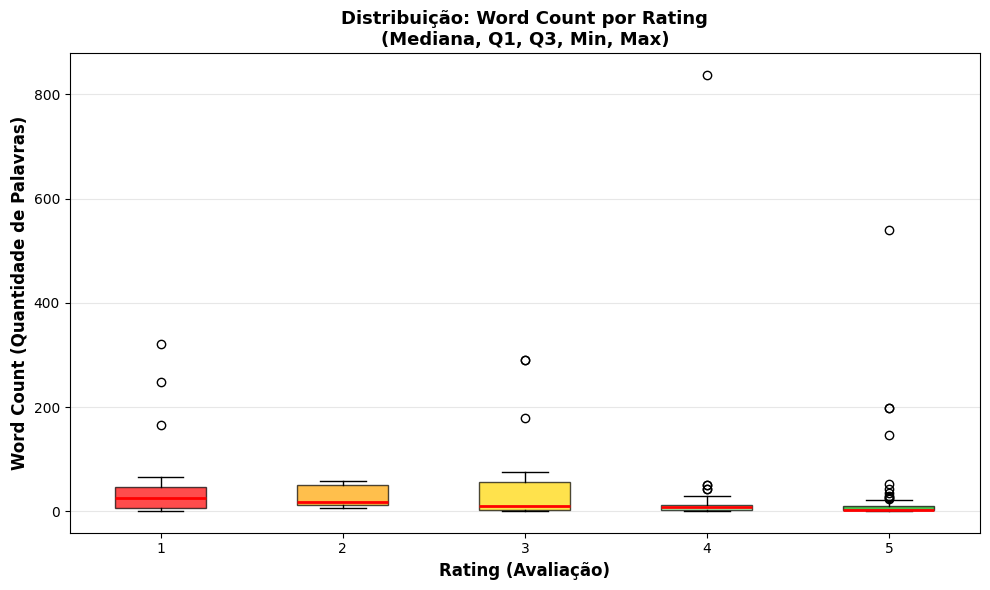

In [ ]:
# Cores baseadas no rating
cores_rating = {
    1.0: '#FF0000',  # Vermelho (muito ruim)
    2.0: '#FFA500',  # Laranja (ruim)
    3.0: '#FFD700',  # Ouro (neutro)
    4.0: '#90EE90',  # Verde claro (bom)
    5.0: '#00AA00'   # Verde escuro (excelente)
}

# Criar figura
fig, ax = plt.subplots(figsize=(10, 6))

# Agrupar word_count por rating
data_por_rating = [df[df["Rating"] == rating]["Word_Count"].values 
                   for rating in sorted(df["Rating"].unique())]

bp = ax.boxplot(data_por_rating, 
                 labels=[str(int(r)) for r in sorted(df["Rating"].unique())],
                 patch_artist=True,
                 medianprops=dict(color='red', linewidth=2))

# Colorir boxes
for patch, rating in zip(bp['boxes'], sorted(df["Rating"].unique())):
    patch.set_facecolor(cores_rating.get(rating, '#808080'))
    patch.set_alpha(0.7)

ax.set_xlabel("Rating (Avaliação)", fontsize=12, fontweight='bold')
ax.set_ylabel("Word Count (Quantidade de Palavras)", fontsize=12, fontweight='bold')
ax.set_title("Distribuição: Word Count por Rating\n(Mediana, Q1, Q3, Min, Max)", 
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show();

In [ ]:
from collections import Counter
import re

# Exemplo 1: Extrair e contar PALAVRAS
def extrair_palavras(texto):
    """Extrai palavras (apenas letras) e retorna em minúsculas"""
    palavras = re.findall(r'\b[a-zá-ú]+\b', texto.lower())
    return palavras

# Aplicar em todos os comentários
todas_palavras = []
for comentario in df["Comments"]:
    todas_palavras.extend(extrair_palavras(str(comentario)))

# Contar com Counter
contagem_palavras = Counter(todas_palavras)

# Top 20 palavras mais frequentes
print("Top 20 palavras mais frequentes:")
for palavra, count in contagem_palavras.most_common(20):
    print(f"{palavra}: {count}")

# Exemplo 2: Extrair padrões específicos (exemplo: números)
def extrair_numeros(texto):
    """Extrai todos os números"""
    numeros = re.findall(r'\d+', str(texto))
    return numeros

numeros_encontrados = []
for comentario in df["Comments"]:
    numeros_encontrados.extend(extrair_numeros(comentario))


Top 20 palavras mais frequentes:
is: 217
the: 191
and: 160
good: 144
in: 124
phone: 121
this: 105
camera: 100
a: 97
i: 97
it: 90
of: 85
to: 85
not: 74
for: 61
very: 55
quality: 54
redmi: 49
with: 49
but: 49


---

## 7. Conclusions and Recommendations

### 7.1 Key Findings Summary
- **Data Quality**: Dataset contains [X] records after deduplication and cleaning
- **Rating Distribution**: [Summary of rating patterns]
- **Category Performance**: [Key insights about category-specific feedback]
- **Comment Characteristics**: [Patterns in word count and engagement metrics]

### 7.2 Recommendations for Further Analysis
1. Implement sentiment analysis on extracted comments
2. Conduct topic modeling for thematic pattern discovery
3. Time-series analysis to identify temporal trends in feedback
4. Correlation analysis between rating and textual features
5. Develop predictive models for comment usefulness classification

### 7.3 Data Quality Metrics
- **Completeness**: [Percentage of non-null records]
- **Uniqueness**: Duplicate records identified and removed
- **Validity**: Data types standardized and validated
- **Consistency**: Field values normalized across dataset

---

**Notebook Version**: 1.0  
**Last Updated**: November 18, 2025  
**Status**: Exploratory Analysis Complete